# **Prerequisites**


> 1. Installing conda in colab (ne condacolab!)

> 2. Import clear_output (keeping colab neat!!!)

In [ ]:
# !pip install -q condacolab
# import condacolab
# condacolab.install()

✨🍰✨ Everything looks OK!


In [ ]:
# from IPython.display import clear_output


---

# 2. How to train a Deep learning model?  - Hands-on
    
---

In this tutorial, we will show you how to:


> 1. Train a Convolutional Neural Network (CNN) on MPRA data


> 2. Evaluate models








# STEP 1

## The Setup - Creating environment and installing dependencies

---




> Fetch our workshop repository from GitHub using `git clone`



In [1]:
!git clone https://github.com/kircherlab/HowToTrainDNN.git

Cloning into 'HowToTrainDNN'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 56 (delta 15), reused 20 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 26.64 MiB | 6.40 MiB/s, done.
Resolving deltas: 100% (15/15), done.


> You can see a folder `HowToTrainDNN` in your Files directory, if not please ask!

---


## Getting a deep neural network (DNN) model

---


>For e.g., how about DeepSTARR? From *Almeida et al., 2022*

>But do they have GitHub repo? - Duh!! offcourse :)





In [2]:
!git clone https://github.com/bernardo-de-almeida/DeepSTARR.git

Cloning into 'DeepSTARR'...
remote: Enumerating objects: 228, done.
remote: Counting objects: 100% (228/228), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 228 (delta 125), reused 160 (delta 57), pack-reused 0 (from 0)
Receiving objects: 100% (228/228), 4.52 MiB | 22.24 MiB/s, done.
Resolving deltas: 100% (125/125), done.


In [3]:
!cd DeepSTARR/DeepSTARR/

## Creating a conda environment

we create a `conda` environment for our DNN model using

```
conda create --name <name-of-environment> package=1 package=2 ...
```
> # 🛈 Note
>This step should take about 3-5 minutes.

---



In [ ]:
# !conda create --name DeepSTARR python=3.7 tensorflow-gpu -y
# clear_output()
# use DeepSTARR37 local environment
add mamba install conda-forge::keras

> Activate environment with `source activate <name-of-environment>`

---

In [ ]:
# !source activate DeepSTARR

## Importing libraries

---

In [2]:
# DNN libraries
import tensorflow as tf
import keras
import keras.layers as kl
from keras.models import Sequential, Model, load_model
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, History, ModelCheckpoint
from keras.layers import Conv1D, MaxPooling1D
from keras.layers import Dropout, Reshape, Dense, Activation, Flatten
from keras.layers import BatchNormalization, InputLayer, Input
from keras import models

# Data-analysis libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

# for reproduciblity
import random
random.seed(42)

# STEP 2


## The Data - Getting MPRA dataset

Here, we will use dataset from the following study.

*Agarwal, V., Inoue, F., Schubach, M., Martin, B.K., Dash, P.M., Zhang, Z., Sohota, A., Noble, W.S., Yardimci, G.G., Kircher, M. and Shendure, J., 2023. **Massively parallel characterization of transcriptional regulatory elements in three diverse human cell types**. bioRxiv.*

---

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# reading a .tsv file
data = pd.read_csv('/content/drive/MyDrive/PhD/neuro_activity_80K/80K_deepStarr_all_regions_sequence.tsv', sep='\t')
data.head()

,BIN,ID,REF_BCalm_logFC,group_idx,sequence
0,7,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,2.056023,0,AGGACCGGATCAACTAATGTAGATTTATGACAGTTTTGAAAAATCA...
1,9,cardiac_neuro_cava_random:RERE|ENSG00000142599...,1.901706,1,AGGACCGGATCAACTTGTTATCACAGTTATTGTTTGTATGTGTGAT...
2,8,cardiac_neuro_cava_random:TCF4|ENSG00000196628...,2.088181,2,AGGACCGGATCAACTAACTGTTATAAATTACCTAGACTTAAGGAAG...
3,8,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,2.287976,3,AGGACCGGATCAACTGGAAAACCATGCCCTCCAGGGACTGCACTAT...
4,9,cardiac_neuro_cava_random:RBM20|ENSG0000020386...,1.768680,4,AGGACCGGATCAACTAGGACAGAACTGTGTGCTGCCTGCTTCACTC...


### Remove adapter (+-15bp)

In [23]:
data['sequence_with_adapter'] = data['sequence']
data['sequence'] = data['sequence_with_adapter'].apply(lambda x: x[15:-15])

data['name'] = data['ID']
data.drop(columns=['ID'], inplace=True)

data['logFC'] = data['REF_BCalm_logFC']
data.drop(columns=['REF_BCalm_logFC'], inplace=True)

In [24]:
data.head()
print(data.shape[0])
print(data.group_idx.nunique())
# print(data.group_idx.value_counts())

63333
513
group_idx
23       1586
0         951
88        741
72        727
1150      595
         ... 
8492        6
9465        6
5304        6
16305       5
51911       1
Name: count, Length: 513, dtype: int64


## Understanding data distribution

---

In [ ]:
# # Set up the matplotlib figure
# fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# for i, (col1, col2) in enumerate([(2, 3), (3, 4), (4, 2)]):
#     # Create a hexbin plot for the joint plot
#     hb = axes[i].hexbin(data.iloc[:, col1], data.iloc[:, col2], gridsize=50, extent=[-2, 2, -2, 2], cmap='Greys')

#     # Calculate and print the Pearson correlation coefficient and p-value
#     corr_coef, p_value = stats.pearsonr(data.iloc[:, col1], data.iloc[:, col2])
#     axes[i].text(-1.5, 1.5, f'pearsonr: {corr_coef:.2f}')

#     # Set the same axes limits for all subplots
#     axes[i].set_xlim([-2, 2])
#     axes[i].set_ylim([-2, 2])

#     # Set the axis labels
#     axes[i].set_xlabel(data.columns[col1])
#     axes[i].set_ylabel(data.columns[col2])

#     # Set ticks in axis per each integer
#     axes[i].set_xticks(np.arange(-2, 3, 1))
#     axes[i].set_yticks(np.arange(-2, 3, 1))

# plt.tight_layout()
# plt.show()

## One-hot encoding
> Let's understand how to one-hot-encode?

<img src="https://media.springernature.com/full/springer-static/image/art%3A10.1007%2Fs00449-022-02716-w/MediaObjects/449_2022_2716_Fig3_HTML.png?as=webp" alt="STARR-seq data" width="600"/>

[Reference](https://link.springer.com/article/10.1007/s00449-022-02716-w)

---

Are there only 4 DNA/RNA nucelotide base annotations?
> Duh! off course not :)

| IUPAC nucleotide code | Base                |
| --------------------- | ------------------- |
| A                     | Adenine             |
| C                     | Cytosine            |
| G                     | Guanine             |
| T (or U)              | Thymine (or Uracil) |
| R                     | A or G              |
| Y                     | C or T              |
| S                     | G or C              |
| W                     | A or T              |
| K                     | G or T              |
| M                     | A or C              |
| B                     | C or G or T         |
| D                     | A or G or T         |
| H                     | A or C or T         |
| V                     | A or C or G         |
| N                     | any base            |

[Source](https://www.bioinformatics.org/sms/iupac.html)

In [26]:
# define a dictionary to map nucleotides to their one-hot encoded representation
nucleotide_dict = {'A': [1, 0, 0, 0],
                   'C': [0, 1, 0, 0],
                   'G': [0, 0, 1, 0],
                   'T': [0, 0, 0, 1],
                   'N': [0, 0, 0, 0]} # what if there's an N

# define a function to one-hot encode a single DNA sequence
def one_hot_encode(seq):
    return np.array([nucleotide_dict[nuc] for nuc in seq])

## Train, test and validation split

---

> Let's split dataset as follows,
  - Input X: sequences as one-hot encoded
  - Output Y: mean MPRA activity (logFC)
  - Split:
    - 90% train
    - 5% test
    - 5% validation

In [47]:
def splitEncode(df, X_cols, y_cols):
    # Split the dataframe into X and y
    X = df[X_cols]
    y = df[y_cols]

    # One-hot encode the X data
    X = np.array(X['sequence'].apply(one_hot_encode).tolist())

    # Split the data into train and test+validation sets (90% and 10%)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.1, random_state=42)

    # Split the test+validation sets into test and validation sets (50% and 50% of 10% => 5% and 5% of total)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    return X_train, X_test, X_val, y_train, y_test, y_val

def useGroupForSplit(data, group_col, x_cols, y_cols):
    """Function which uses groups to split train and test (e.g. regions associated to the same gene or different genes)"""
    if (type(y_cols) == str):
        y_cols = [y_cols] # because I want to have the shape to be x, 1 no x,
    # Step 1: First split into train (90%) and test (10%)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
    train_idx, test_idx = next(gss.split(data, groups=data[group_col]))

    train_df = data.iloc[train_idx]
    test_df = data.iloc[test_idx]

    # Step 2: Split the test set into test (50%) and validation (50%)
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    test_idx, val_idx = next(gss_test.split(test_df, groups=test_df[group_col]))

    final_test_df = test_df.iloc[test_idx]
    val_df = test_df.iloc[val_idx]

    x_train = np.array(train_df[x_cols].apply(one_hot_encode).tolist())
    y_train = train_df[y_cols]
    x_test = np.array(final_test_df[x_cols].apply(one_hot_encode).tolist())
    y_test = final_test_df[y_cols]
    x_val = np.array(val_df[x_cols].apply(one_hot_encode).tolist())
    y_val = val_df[y_cols]
    return x_train, x_test, x_val, y_train, y_test, y_val



### Testing if the test train split was working

In [17]:
#### Testing if the train test split was working

# import pandas as pd
# from sklearn.model_selection import GroupShuffleSplit

# # Step 1: First split into train (90%) and test (10%)
# gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
# train_idx, test_idx = next(gss.split(data, groups=data['group_idx']))

# train_df = data.iloc[train_idx]
# test_df = data.iloc[test_idx]

# # Step 2: Split the test set into test (50%) and validation (50%)
# gss_test = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
# test_idx, val_idx = next(gss_test.split(test_df, groups=test_df['group_idx']))

# final_test_df = test_df.iloc[test_idx]
# val_df = test_df.iloc[val_idx]


# unique_bins_train = list(train_df['group_idx'].unique())
# unique_bins_test = list(test_df['group_idx'].unique())
# unique_bins_final_testing = list(final_test_df['group_idx'].unique())
# unique_bins_final_validation = list(val_df['group_idx'].unique())

# print(unique_bins_train)
# print(unique_bins_test)
# print(unique_bins_final_testing)
# print(unique_bins_final_validation)

# set_unique_bins_final_validation = set(unique_bins_final_validation)
# set_unique_bins_final_testing = set(unique_bins_final_testing)
# set_unique_bins_train = set(unique_bins_train)
# # check overlap:
# print(set_unique_bins_train.intersection(set_unique_bins_final_testing))
# print(set_unique_bins_train.intersection(set_unique_bins_final_validation))
# print(set_unique_bins_final_validation.intersection(set_unique_bins_final_testing))

### let's split

In [48]:
# x_train, x_test, x_val, y_train, y_test, y_val = splitEncode(data, ['sequence'], ['logFC'])
x_train, x_test, x_val, y_train, y_test, y_val = useGroupForSplit(data,group_col='group_idx', x_cols='sequence', y_cols='logFC')
pd.DataFrame({
    'Dataset': ['x_train', 'x_test', 'x_val', 'y_train', 'y_test', 'y_val'],
    'Shape': [x_train.shape, x_test.shape, x_val.shape, y_train.shape, y_test.shape, y_val.shape]
})


,Dataset,Shape
0,x_train,"(56557, 270, 4)"
1,x_test,"(3455, 270, 4)"
2,x_val,"(3321, 270, 4)"
3,y_train,"(56557, 1)"
4,y_test,"(3455, 1)"
5,y_val,"(3321, 1)"


## Setting hyperparamters
> Here, we are going to use an optimized set of `params` (aka hyperparamters or model features) from the DeepSTARR study.

NOTE: Importance of hyperparamters
  - **Importance**: They define the model structure and learning process, significantly influencing performance.
  - **Achievement**: Set before training, determined by trial and error, or systematic search processes.
  - **Time**: Tuning hyperparameters is time-consuming as each configuration requires training a new model. Plan accordingly.

In [57]:
# params = {'batch_size': 64, # number of examples per batch
#                       'epochs': 100, # number of epochs
#                       'early_stop': 10, # patience of 10 epochs to reduce training time; you can increase the patience to see if the model improves after more epochs
#                       'lr': 0.001, # learning rate
#                       'n_conv_layer': 3, # number of convolutional layers
#                       'num_filters1': 128, # number of filters/kernels in the first conv layer
#                       'num_filters2': 60, # number of filters/kernels in the second conv layer
#                       'num_filters3': 60, # number of filters/kernels in the third conv layer
#                       # 'num_filters4': 120,
#                       'kernel_size1': 7, # size of the filters in the first conv layer
#                       'kernel_size2': 3, # size of the filters in the second conv layer
#                       'kernel_size3': 5, # size of the filters in the third conv layer
#                       # 'kernel_size4': 3,
#                       'n_dense_layer': 1, # number of dense/fully connected layers
#                       'dense_neurons1': 64, # number of neurons in the dense layer
#                       # 'dense_neurons2': 256,
#                       'dropout_conv': 'yes', # add dropout after convolutional layers?
#                       'dropout_prob': 0.4, # dropout probability
#                       'pad':'same'}

params = {'batch_size': 128,
          'epochs': 100,
          'early_stop': 10,
          'kernel_size1': 7,
          'kernel_size2': 3,
          'kernel_size3': 5,
          'kernel_size4': 3,
          'lr': 0.002,
          'num_filters': 256,
          'num_filters2': 60,
          'num_filters3': 60,
          'num_filters4': 120,
          'n_conv_layer': 4,
          'n_add_layer': 2,
          'dropout_prob': 0.4,
          'dense_neurons1': 256,
          'dense_neurons2': 256,
          'pad':'same'}


## Model configuration - Setting input and output

> We will follow the DeepSTARR model structure.

In [58]:
### Additional metrics for training purpose
def Spearman(y_true, y_pred):
     return ( tf.py_function(spearmanr, [tf.cast(y_pred, tf.float32),
                       tf.cast(y_true, tf.float32)], Tout = tf.float32) )


In [65]:
def DeepSTARR(params=params):

    lr = params['lr']
    dropout_prob = params['dropout_prob']
    n_conv_layer = params['n_conv_layer']
    n_add_layer = params['n_add_layer']

    # body
    input = kl.Input(shape=(270, 4))
    x = kl.Conv1D(params['num_filters'], kernel_size=params['kernel_size1'],
                  padding=params['pad'],
                  name='Conv1D_1st')(input)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(2)(x)

    for i in range(1, n_conv_layer):
        x = kl.Conv1D(params['num_filters'+str(i+1)],
                      kernel_size=params['kernel_size'+str(i+1)],
                      padding=params['pad'],
                      name=str('Conv1D_'+str(i+1)))(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = MaxPooling1D(2)(x)

    x = Flatten()(x)

    # dense layers
    for i in range(0, n_add_layer):
        x = kl.Dense(params['dense_neurons'+str(i+1)],
                     name=str('Dense_'+str(i+1)))(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout_prob)(x)
    bottleneck = x

    # heads per task (developmental and housekeeping enhancer activities)
    tasks = ['Dev', 'Hk']
    outputs = []
    for task in tasks:
        outputs.append(kl.Dense(1, activation='linear', name=str('Dense_' + task))(bottleneck))

    model = keras.models.Model([input], outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss=['mse', 'mse'], # loss
                  loss_weights=[1, 1], # loss weigths to balance
                  metrics=[Spearman]) # additional track metric

    return model, params

DeepSTARR()[0].summary()
DeepSTARR()[1] # dictionary

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9             │ (None, 270, 4)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1D_1st (Conv1D)       │ (None, 270, 256)       │          7,424 │ input_layer_9[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_40    │ (None, 270, 256)       │          1,024 │ Conv1D_1st[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_40             │ (None, 270, 256)       │              0 │ batch_normalization_4… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_28          │ (None, 135, 256)       │              0 │ activation_40[0][0]    │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1D_2 (Conv1D)         │ (None, 135, 60)        │         46,140 │ max_pooling1d_28[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_41    │ (None, 135, 60)        │            240 │ Conv1D_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_41             │ (None, 135, 60)        │              0 │ batch_normalization_4… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_29          │ (None, 67, 60)         │              0 │ activation_41[0][0]    │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1D_3 (Conv1D)         │ (None, 67, 60)         │         18,060 │ max_pooling1d_29[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_42    │ (None, 67, 60)         │            240 │ Conv1D_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_42             │ (None, 67, 60)         │              0 │ batch_normalization_4… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_30          │ (None, 33, 60)         │              0 │ activation_42[0][0]    │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1D_4 (Conv1D)         │ (None, 33, 120)        │         21,720 │ max_pooling1d_30[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4

 Total params: 655,458 (2.50 MB)

 Trainable params: 653,442 (2.49 MB)

 Non-trainable params: 2,016 (7.88 KB)

{'batch_size': 128,
 'epochs': 100,
 'early_stop': 10,
 'kernel_size1': 7,
 'kernel_size2': 3,
 'kernel_size3': 5,
 'kernel_size4': 3,
 'lr': 0.002,
 'num_filters': 256,
 'num_filters2': 60,
 'num_filters3': 60,
 'num_filters4': 120,
 'n_conv_layer': 4,
 'n_add_layer': 2,
 'dropout_prob': 0.4,
 'dense_neurons1': 256,
 'dense_neurons2': 256,
 'pad': 'same'}

# STEP 3

---

## Training a DNN
> Now, we are ready to start model training.

In [66]:
main_model, main_params = DeepSTARR(params)

In [67]:
# Ensure model is compiled
main_model.compile(optimizer='adam', loss='mean_squared_error')


In [68]:
def train(selected_model, X_train, Y_train, X_valid, Y_valid, params):

    my_history=selected_model.fit(X_train, Y_train,
                                  validation_data=(X_valid, Y_valid), epochs=params['epochs'],
                                  callbacks=[EarlyStopping(patience=params['early_stop'], monitor="val_loss", restore_best_weights=True),
                                             History()])

    return selected_model, my_history


main_model, my_history = train(main_model, x_train, y_train, x_val, y_val, params)

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:664: UserWarning: Gradients do not exist for variables ['kernel', 'bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


1768/1768 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 0.4513 - val_loss: 0.1205
Epoch 2/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 0.1159 - val_loss: 0.1112
Epoch 3/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0969 - val_loss: 0.1443
Epoch 4/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0845 - val_loss: 0.1457
Epoch 5/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0732 - val_loss: 0.1346
Epoch 6/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0622 - val_loss: 0.1898
Epoch 7/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0556 - val_loss: 0.1307
Epoch 8/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0503 - val_loss: 0.1126
Epoch 9/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0471 - val_loss: 0.1327
Epoch 10/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0437 - val_loss: 0.1211
Epoch 11/100
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0417 - val_loss: 0.1776
Epoch 12/100
1768/1768 ━

## Things to remember

---

# STEP 4

---

## Model evaluation

> It's time to evaluate our model.
  - Did it ***PASS***, or ***FAIL***, or the ***BEST***!

### Understand training

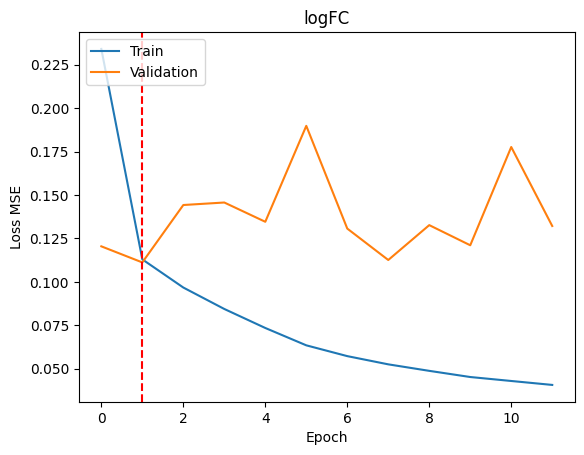

In [69]:
# Plot training & validation training metrics
# MSE
plt.plot(my_history.history[str('loss')])
plt.plot(my_history.history[str('val_loss')])
plt.title('logFC') # loss is Mean Squared Error (MSE)
plt.ylabel('Loss MSE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Add vertical line at minimum validation loss of combined dev and hk
min_val_loss = min(my_history.history['val_loss'])
plt.axvline(x=my_history.history['val_loss'].index(min_val_loss), color='red', linestyle='--')

plt.show()

### Performance metrics

In [79]:
def evaluate_model(X, y, model):
    # Predict the output
    y_pred = model.predict(X)
    # Reshape the arrays to be one-dimensional
    y = y.values.reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)
    print
    # Calculate metrics
    mse = mean_squared_error(y, y_pred)
    pcc, _ = pearsonr(y, y_pred)
    scc, _ = spearmanr(y, y_pred)

    # Create a DataFrame for the table
    metrics_df = pd.DataFrame({
        'Metric': ['MSE', 'PCC', 'SCC'],
        'Value': [mse, pcc, scc]
    })

    # Print the table
    print(metrics_df)

In [80]:
y_val.values.reshape(-1)
y_pred = main_model.predict(x_val)
type(y_pred)
np.array(y_pred).reshape(-1)

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([-0.09634013, -0.08644538, -0.03304133, ...,  0.47308004,
       -0.55471563, -0.40048844], dtype=float32)

In [86]:
x_val.shape[0]
y_val.shape[0]
main_model

<Functional name=functional_10, built=True>

In [87]:
evaluate_model(x_val, y_val, main_model)

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


ValueError: Found input variables with inconsistent numbers of samples: [3321, 6642]

In [ ]:
evaluate_model(X_test, y_test, main_model)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
  Metric     Value
0    MSE  0.063266
1    PCC  0.329836
2    SCC  0.346792


### Plotting data - A model perspective

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


<ipython-input-21-8b4b2ce82252>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


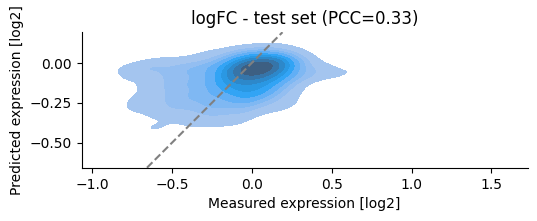

In [ ]:
### smoothscatter plot - useful when there are thousands of points

# takes some time to calculate the kernel density
def my_scatter_density(X, Y, set, task):
  pred = main_model.predict(X, batch_size=main_params['batch_size'])

  # Convert DataFrames to numpy arrays and reshape to be one-dimensional
  Y = Y.values.reshape(-1)
  pred = pred.reshape(-1)

  g = sns.jointplot(x=Y, y=pred, kind="kde", fill=True)
  g.ax_marg_x.remove() # remove marginal densities
  g.ax_marg_y.remove() # remove marginal densities

  # add expected regression line
  x0, x1 = g.ax_joint.get_xlim()
  y0, y1 = g.ax_joint.get_ylim()
  lims = [max(x0, y0), min(x1, y1)]
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')

  # same axes ranges
  g.ax_joint.set_aspect('equal')

  PCC = str("{0:0.2f}".format(stats.pearsonr(Y, pred)[0]))
  plt.xlabel('Measured expression [log2]')
  plt.ylabel('Predicted expression [log2]')
  plt.title(str(task + ' - ' + set + ' set (PCC=' + PCC + ')'))

  plt.show()

# print plots for test sets
my_scatter_density(X_test, y_test, "test", "logFC")

# Saving your model

---

In [ ]:
# save your model weights and structure as it is
main_model.save('/content/drive/MyDrive/PhD/neuro_activity_80K/tested_elements_DeepSTARR_model.keras')